In [1]:
import pandas as pd

# Faylın əvvəlinə sadəcə ~/ artırırıq ki, ana səhifədə olduğunu bilsin
df = pd.read_excel('~/yeni_data.xltx')

df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [2]:
print(df.columns)

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')


In [9]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [5]:
duzelisler = {
    'LF':'Low Fat',
    'reg':'Low Fat',
    'low fat':'Low Fat'
}
df['Item Fat Content'] = df['Item Fat Content'].replace(duzelisler)
df['Item Fat Content'].value_counts()


Item Fat Content
Low Fat    5634
Regular    2889
Name: count, dtype: int64

In [4]:
magaza_satislari = df.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)
print(magaza_satislari)

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64


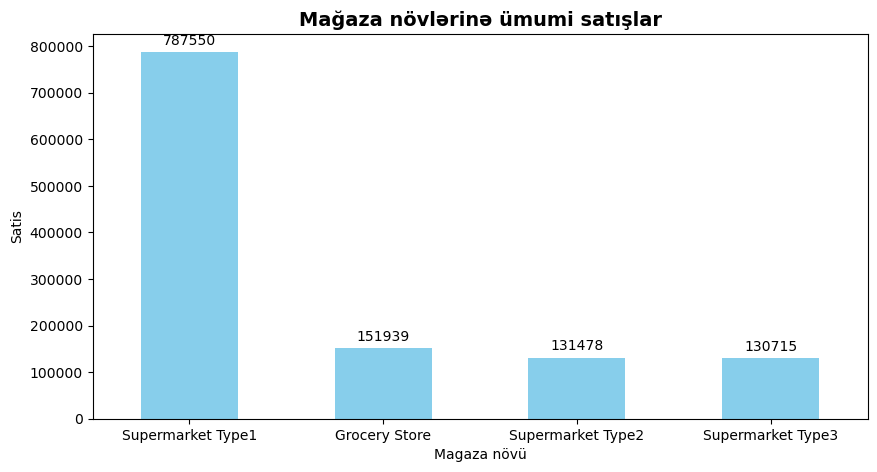

In [6]:
import matplotlib.pyplot as plt
ax = magaza_satislari.plot(kind='bar',color='skyblue',figsize= (10,5))
plt.title ('Mağaza növlərinə ümumi satışlar',fontsize =14,fontweight = 'bold')
plt.xlabel ('Magaza növü')
plt.ylabel ('Satis')
ax.bar_label(ax.containers[0],fmt='%.0f',padding = 3)
plt.xticks(rotation=0)
plt.show()

In [9]:
print(df.isnull().sum())

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64


In [9]:
orta_ceki = df['Item Weight'].mean()
print(f"Butun mehsullarin orta cekisi:{orta_ceki}")
df['Item Weight'] = df['Item Weight'].fillna(orta_ceki)
print(df.isnull().sum())

Butun mehsullarin orta cekisi:12.857645184135977
Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64


In [3]:
import matplotlib.pyplot as plt
top_5_satis = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False).head(5)
ax = top_5_satis.sort_values().plot(kind = barh,color = 'coral',figsize = (10,5))
plt.title('Ən Çox Qazandıran TOP 5 Məhsul Növü',fontsize = 14,fontweight = 'bold')
plt.xlabel('Umumi satis($)')
plt.ylabel('Məhsul Kateqoriyası')
ax.bar_label(ax.containers[0],fmt = '%.f0',padding = 0)
plt.show()

NameError: name 'barh' is not defined

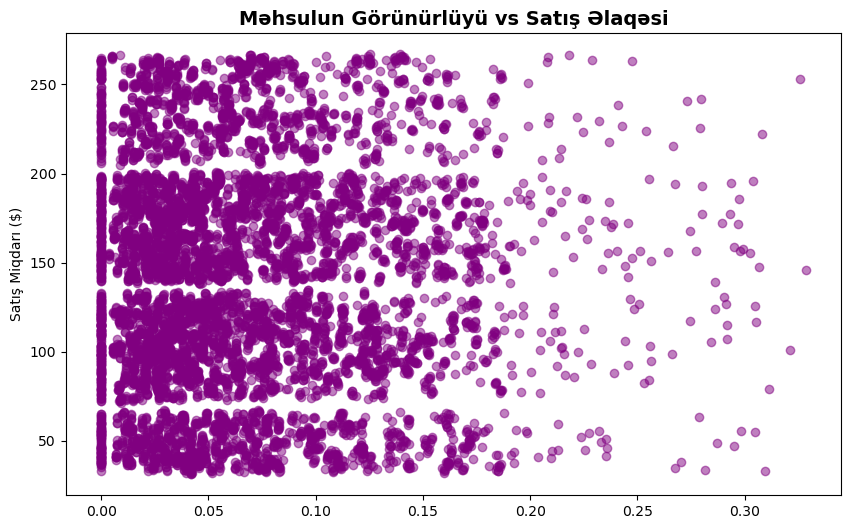

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.scatter(df['Item Visibility'],df['Sales'],alpha = 0.5,color = 'purple')
plt.title('Məhsulun Görünürlüyü vs Satış Əlaqəsi',fontsize = 14,fontweight='bold')
plt.ylabel('Satış Miqdarı ($)')
plt.show()

In [12]:
df['Item Visibility'].corr(df['Sales'])

np.float64(-0.0013149598375738435)

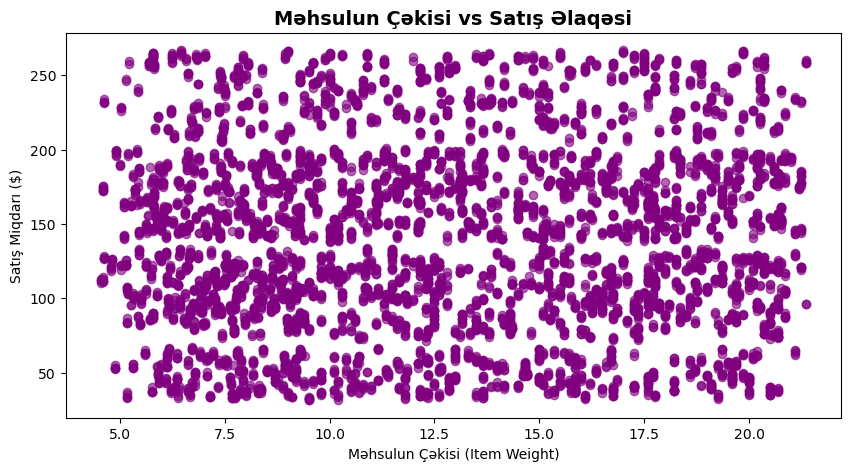

In [4]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 5))

# X oxuna Çəki, Y oxuna isə Satış məlumatlarını veririk
plt.scatter(df['Item Weight'], df['Sales'], color='purple', alpha=0.6)

# Başlığı və oxların adlarını dataya uyğun düzəldirik

plt.title('Məhsulun Çəkisi vs Satış Əlaqəsi', fontsize=14, fontweight='bold')
plt.xlabel('Məhsulun Çəkisi (Item Weight)')
plt.ylabel('Satış Miqdarı ($)')

# Qrafiki ekrana çıxarırıq
plt.show()

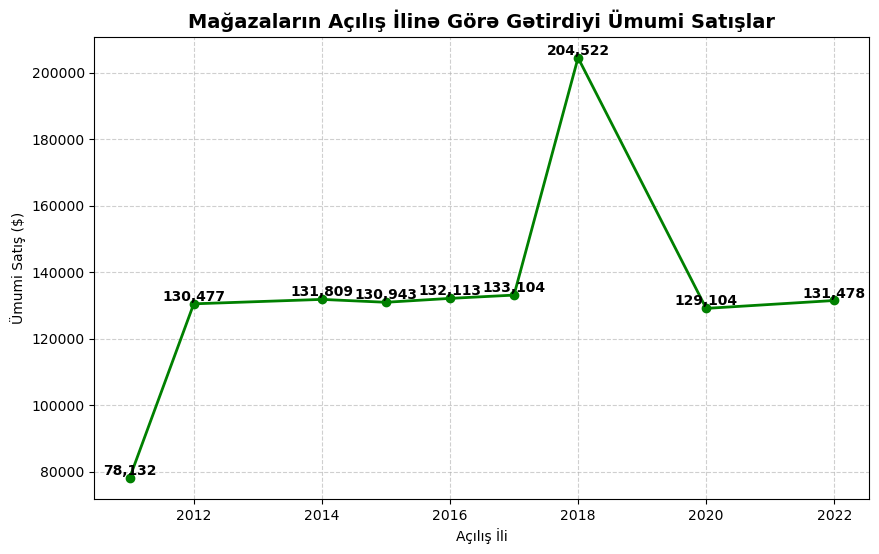

In [4]:
import matplotlib.pyplot as plt
iller_uzre_satislar = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize = (10,6))
plt.plot(iller_uzre_satislar.index,iller_uzre_satislar.values,color = 'green',marker = 'o',linewidth = 2)
plt.title('Mağazaların Açılış İlinə Görə Gətirdiyi Ümumi Satışlar',fontweight = 'bold',fontsize = 14)
plt.ylabel('Ümumi Satış ($)')
plt.xlabel('Açılış İli')
plt.grid(True, linestyle='--', alpha=0.6)
for il,satis in zip(iller_uzre_satislar.index, iller_uzre_satislar.values):
    plt.text(il,satis,f"{satis:,.0f}",ha='center',va = 'bottom',fontsize = 10,fontweight = 'bold')
    
plt.show()

In [6]:
magaza_sayi = df['Outlet Establishment Year'].value_counts().sort_values()
print("İllər üzrə açılan mağaza sayı:")
print(magaza_sayi)

İllər üzrə açılan mağaza sayı:
Outlet Establishment Year
2011     555
2020     926
2022     928
2015     929
2012     930
2016     930
2017     930
2014     932
2018    1463
Name: count, dtype: int64


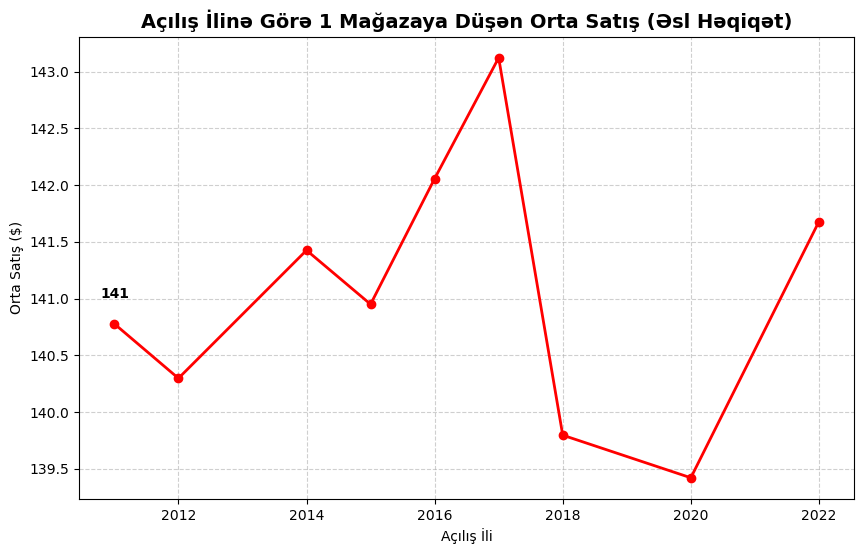

In [ ]:
orta_satislar = df.groupby('Outlet Establishment Year')['Sales'].mean().sort_index()
plt.figure(figsize = (10,6))
plt.plot(orta_satislar.index,orta_satislar.values,color = 'red',marker = 'o',linewidth = 2)
plt.title('Açılış İlinə Görə 1 Mağazaya Düşən Orta Satış (Əsl Həqiqət)', fontsize=14, fontweight='bold')
plt.ylabel('Orta Satış ($)')
plt.xlabel('Açılış İli')
plt.grid(True,linestyle = '--',alpha = 0.6)

for il,satis  in zip(orta_satislar.index,orta_satislar.values):
    plt.text(il,satis+0.2,f"{satis:,.0f}",ha = 'center',va = 'bottom',fontsize = 10,fontweight = 'bold')
    plt.show()

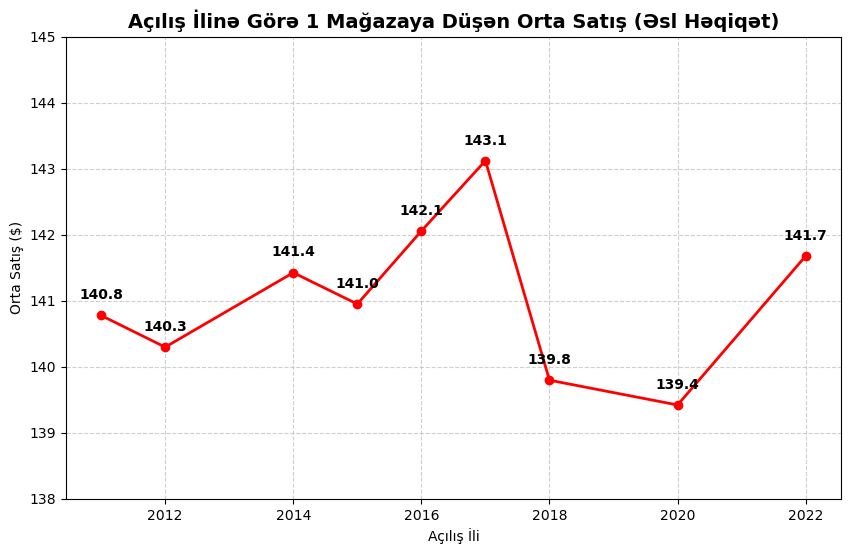

In [2]:
import matplotlib.pyplot as plt

orta_satislar = df.groupby('Outlet Establishment Year')['Sales'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(orta_satislar.index, orta_satislar.values, color='red', marker='o', linewidth=2)

plt.title('Açılış İlinə Görə 1 Mağazaya Düşən Orta Satış (Əsl Həqiqət)', fontsize=14, fontweight='bold')
plt.ylabel('Orta Satış ($)')
plt.xlabel('Açılış İli')
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(138, 145)

for il, satis in zip(orta_satislar.index, orta_satislar.values):
    plt.text(il, satis + 0.2, f"{satis:,.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()